# 20. Causal Analysis Agent

A causal analysis agent is not a magic analyst. It is a workflow controller that turns a project brief into structured intermediate artifacts: an estimand card, variable-role screen, design recommendation, diagnostic checks, estimates, and a report draft.

The goal of this notebook is to build a small but auditable causal analysis agent. The deterministic tools will do the statistical work. The LLM will propose and critique plans. Human review gates will decide whether the workflow should proceed.

## Learning Goals

By the end of this notebook, you should be able to:

- Define an agent state for causal analysis workflows.
- Separate LLM planning from deterministic statistical tools.
- Build tools for profiling data, screening variable roles, selecting an identification strategy, running diagnostics, and estimating effects.
- Add human review gates that prevent the agent from silently using bad controls or weak designs.
- Use structured LLM outputs for agent plans and critiques.
- Score agent plans across model families for causal reasoning, brittleness, and unsafe automation.

## Live Model Note

Agent notebooks are especially brittle because errors compound. A model can make a small mistake in the project brief, carry that mistake into the adjustment set, choose a bad control, run the wrong estimator, and then write a confident report. A multi-step agent can therefore look more impressive while being less safe.

This notebook treats brittleness as a design constraint. The agent must leave an audit trail, use deterministic tools for computations, clear model memory between model-family comparisons, and stop at human review gates when assumptions are not credible.

## 1. Setup

We will use a synthetic customer-retention project. The treatment is not randomized: high-risk customers are more likely to receive a concierge retention offer. That makes naive treated-versus-control comparisons misleading and gives the agent a realistic design problem.

In [1]:
import json
import re
import sys
import warnings
from copy import deepcopy
from pathlib import Path
from typing import Any, Literal

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from IPython.display import Markdown, display
from pydantic import BaseModel, Field

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')

PROJECT_ROOT = Path.cwd()
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'notebooks' / '_shared' / 'local_llm.py').exists():
        PROJECT_ROOT = candidate
        break

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')

Project root: /home/apex/Documents/portfolio


In [2]:
RUN_LIVE_LOCAL_LLM = True
RUN_FULL_MODEL_COMPARISON = True
RUN_SCHEMA_REPAIR_RETRY = True

MODEL_ID = 'Qwen/Qwen2.5-14B-Instruct'
MAX_NEW_TOKENS = 2200
COMPACT_MAX_NEW_TOKENS = 950
TEMPERATURE = 0.0
SEED = 220
MODEL_COMPARISON_CASE_LIMIT = 3

try:
    import torch
    print(f'CUDA available to this kernel: {torch.cuda.is_available()}')
except Exception as exc:
    print(f'Torch availability check failed: {exc}')

CUDA available to this kernel: True


In [3]:
try:
    from notebooks._shared.local_llm import DEFAULT_MODELS_TO_COMPARE
except Exception:
    DEFAULT_MODELS_TO_COMPARE = [('Qwen 14B', MODEL_ID, 'strong local analysis')]

MODELS_TO_COMPARE = DEFAULT_MODELS_TO_COMPARE
pd.DataFrame(MODELS_TO_COMPARE, columns=['label', 'model_id', 'role'])

,label,model_id,role
0,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test
1,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default
2,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis
3,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison
5,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison
6,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison
7,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison
8,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline


## 2. What a Causal Agent Should and Should Not Do

A useful causal analysis agent can:

- Read a project brief and extract the decision, treatment, outcome, unit, and candidate variables.
- Create an estimand card.
- Screen variable roles before modeling.
- Recommend a design class and list assumptions.
- Run deterministic diagnostics and estimators.
- Produce a report draft that is grounded in computed artifacts.

A dangerous causal analysis agent will:

- Treat every business question as an estimation problem.
- Use post-treatment variables as controls.
- Skip overlap checks.
- Hallucinate variables or diagnostics.
- Treat a fluent report as evidence that the design is credible.
- Keep going after a human gate should have stopped it.

## 3. Running Example: Targeted Retention Concierge

A subscription company offered a concierge retention intervention to customers at risk of churn. The business question is whether the intervention increases 60-day renewal.

The assignment process is targeted, not randomized. High-risk customers are more likely to receive the offer. This creates confounding: treated customers are different before treatment.

The agent must not simply compare treated and untreated customers. It should identify the design as observational adjustment, screen controls, check overlap, estimate effects with adjustment/IPW/AIPW-style tools, and flag residual assumptions.

In [4]:
project_brief = {
    'project_id': 'retention_concierge_observational_v1',
    'decision': 'Should the company expand a concierge retention offer to more at-risk subscription customers?',
    'unit': 'customer_account',
    'treatment': 'concierge_offer',
    'outcome': 'renewed_60d',
    'time_horizon': '60 days after offer eligibility',
    'assignment_context': 'Customer-success managers prioritized accounts using churn-risk signals and available capacity.',
    'candidate_variables': [
        'segment',
        'tenure_months',
        'monthly_spend',
        'prior_usage_30d',
        'support_tickets_prior_30d',
        'risk_score_pre',
        'concierge_offer',
        'support_contacts_after_offer',
        'renewed_60d',
    ],
    'business_risk': 'Expanding the program may consume expensive customer-success capacity.',
}

print(json.dumps(project_brief, indent=2))

{
  "project_id": "retention_concierge_observational_v1",
  "decision": "Should the company expand a concierge retention offer to more at-risk subscription customers?",
  "unit": "customer_account",
  "treatment": "concierge_offer",
  "outcome": "renewed_60d",
  "time_horizon": "60 days after offer eligibility",
  "assignment_context": "Customer-success managers prioritized accounts using churn-risk signals and available capacity.",
  "candidate_variables": [
    "segment",
    "tenure_months",
    "monthly_spend",
    "prior_usage_30d",
    "support_tickets_prior_30d",
    "risk_score_pre",
    "concierge_offer",
    "support_contacts_after_offer",
    "renewed_60d"
  ],
  "business_risk": "Expanding the program may consume expensive customer-success capacity."
}


## 4. Simulating the Retention Data

The simulation has a known data-generating process, but the agent will not be allowed to use that truth during the analysis. It sees only the project brief, the variable dictionary, and the observed data.

The true treatment effect is positive. However, because the intervention is targeted to high-risk customers, the naive treated-versus-control difference can be too pessimistic.

In [5]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def simulate_retention_data(n=5600, seed=SEED):
    rng = np.random.default_rng(seed)
    segment = rng.choice(['consumer', 'smb', 'mid_market', 'enterprise'], size=n, p=[0.38, 0.31, 0.22, 0.09])
    segment_value = {'consumer': -0.15, 'smb': 0.00, 'mid_market': 0.20, 'enterprise': 0.35}

    tenure_months = rng.gamma(shape=3.2, scale=5.0, size=n).clip(1, 60)
    monthly_spend = np.exp(rng.normal(3.8, 0.55, size=n)) * np.select(
        [segment == 'enterprise', segment == 'mid_market', segment == 'smb'],
        [5.2, 2.6, 1.35],
        default=1.0,
    )
    prior_usage_30d = np.maximum(0, rng.normal(8.5 + 0.08 * tenure_months + np.vectorize(segment_value.get)(segment), 2.4, size=n))
    support_tickets_prior_30d = rng.poisson(np.exp(-0.2 + 0.09 * prior_usage_30d + 0.20 * (segment == 'enterprise')))

    risk_latent = (
        0.85
        - 0.055 * tenure_months
        - 0.23 * prior_usage_30d
        + 0.12 * support_tickets_prior_30d
        - 0.0007 * monthly_spend
        - 0.15 * (segment == 'enterprise')
        + rng.normal(0, 0.7, size=n)
    )
    risk_score_pre = sigmoid(risk_latent)

    treatment_logit = (
        -1.35
        + 2.35 * risk_score_pre
        + 0.16 * support_tickets_prior_30d
        + 0.45 * (segment == 'enterprise')
        + 0.20 * (segment == 'mid_market')
        - 0.03 * prior_usage_30d
    )
    treatment_probability = sigmoid(treatment_logit)
    concierge_offer = rng.binomial(1, treatment_probability)

    baseline_renewal_logit = (
        0.25
        - 1.75 * risk_score_pre
        + 0.11 * prior_usage_30d
        + 0.018 * tenure_months
        + 0.0005 * monthly_spend
        + np.vectorize(segment_value.get)(segment)
    )
    treatment_effect_logit = 0.42 + 0.22 * (risk_score_pre > 0.65) - 0.08 * (segment == 'consumer')
    p0 = sigmoid(baseline_renewal_logit)
    p1 = sigmoid(baseline_renewal_logit + treatment_effect_logit)

    renewed_60d = rng.binomial(1, np.where(concierge_offer == 1, p1, p0))
    support_contacts_after_offer = rng.poisson(
        np.exp(-0.25 + 0.42 * concierge_offer + 0.26 * risk_score_pre + 0.06 * support_tickets_prior_30d)
    )

    df = pd.DataFrame({
        'customer_id': np.arange(n),
        'segment': segment,
        'tenure_months': tenure_months,
        'monthly_spend': monthly_spend,
        'prior_usage_30d': prior_usage_30d,
        'support_tickets_prior_30d': support_tickets_prior_30d,
        'risk_score_pre': risk_score_pre,
        'concierge_offer': concierge_offer,
        'support_contacts_after_offer': support_contacts_after_offer,
        'renewed_60d': renewed_60d,
        'true_expected_effect': p1 - p0,
    })
    return df


df = simulate_retention_data()
df.head()

,customer_id,segment,tenure_months,monthly_spend,prior_usage_30d,support_tickets_prior_30d,risk_score_pre,concierge_offer,support_contacts_after_offer,renewed_60d,true_expected_effect
0,0,mid_market,32.863530,222.718665,14.816889,2,0.013962,0,6,1,0.019629
1,1,consumer,6.110041,61.482274,7.611823,0,0.181120,0,2,1,0.068875
2,2,mid_market,4.554306,96.401421,10.807344,1,0.127389,0,1,1,0.052844
3,3,enterprise,5.395075,139.838246,13.480949,1,0.051242,0,0,1,0.032957
4,4,consumer,29.473734,23.046311,12.799307,5,0.068770,0,1,1,0.033122


In [6]:
observed_summary = (
    df.assign(treatment_label=lambda d: np.where(d['concierge_offer'] == 1, 'offered concierge', 'not offered'))
    .groupby('treatment_label')
    .agg(
        accounts=('customer_id', 'size'),
        renewal_rate=('renewed_60d', 'mean'),
        risk_score_pre=('risk_score_pre', 'mean'),
        prior_usage_30d=('prior_usage_30d', 'mean'),
        support_tickets_prior_30d=('support_tickets_prior_30d', 'mean'),
        support_contacts_after_offer=('support_contacts_after_offer', 'mean'),
    )
    .reset_index()
)
observed_summary

,treatment_label,accounts,renewal_rate,risk_score_pre,prior_usage_30d,support_tickets_prior_30d,support_contacts_after_offer
0,not offered,3942,0.798326,0.135266,9.916460,1.981735,0.907915
1,offered concierge,1658,0.820265,0.173789,9.549959,2.328106,1.471653


In [7]:
true_ate = df['true_expected_effect'].mean()
naive_difference = (
    df.loc[df['concierge_offer'] == 1, 'renewed_60d'].mean()
    - df.loc[df['concierge_offer'] == 0, 'renewed_60d'].mean()
)

pd.DataFrame([
    {'quantity': 'naive treated-control difference', 'value': naive_difference},
    {'quantity': 'true expected ATE visible only in simulation', 'value': true_ate},
])

,quantity,value
0,naive treated-control difference,0.021940
1,true expected ATE visible only in simulation,0.054033


## 5. Variable Dictionary and Role Screen

The agent gets a variable dictionary. In a real project, this dictionary would come from data documentation, product owners, and analysts. The agent should not guess variable timing from column names alone.

The key trap here is `support_contacts_after_offer`. It is post-treatment. A naive agent may use it as a control because it predicts renewal, but controlling for it would block part of the treatment pathway and introduce post-treatment bias.

In [8]:
variable_dictionary = [
    {'variable': 'segment', 'role': 'pre_treatment_confounder', 'timing': 'pre', 'description': 'Customer segment before treatment eligibility.'},
    {'variable': 'tenure_months', 'role': 'pre_treatment_confounder', 'timing': 'pre', 'description': 'Months since subscription started.'},
    {'variable': 'monthly_spend', 'role': 'pre_treatment_confounder', 'timing': 'pre', 'description': 'Monthly spend before the offer decision.'},
    {'variable': 'prior_usage_30d', 'role': 'pre_treatment_confounder', 'timing': 'pre', 'description': 'Usage in the 30 days before offer eligibility.'},
    {'variable': 'support_tickets_prior_30d', 'role': 'pre_treatment_confounder', 'timing': 'pre', 'description': 'Support tickets before offer eligibility.'},
    {'variable': 'risk_score_pre', 'role': 'pre_treatment_confounder', 'timing': 'pre', 'description': 'Pre-treatment churn-risk score used in prioritization.'},
    {'variable': 'concierge_offer', 'role': 'treatment', 'timing': 'treatment', 'description': 'Whether the account received the concierge offer.'},
    {'variable': 'support_contacts_after_offer', 'role': 'post_treatment_variable', 'timing': 'post', 'description': 'Support contacts after the offer decision.'},
    {'variable': 'renewed_60d', 'role': 'outcome', 'timing': 'post', 'description': 'Whether the account renewed within 60 days.'},
]

role_table = pd.DataFrame(variable_dictionary)
role_table

,variable,role,timing,description
0,segment,pre_treatment_confounder,pre,Customer segment before treatment eligibility.
1,tenure_months,pre_treatment_confounder,pre,Months since subscription started.
2,monthly_spend,pre_treatment_confounder,pre,Monthly spend before the offer decision.
3,prior_usage_30d,pre_treatment_confounder,pre,Usage in the 30 days before offer eligibility.
4,support_tickets_prior_30d,pre_treatment_confounder,pre,Support tickets before offer eligibility.
5,risk_score_pre,pre_treatment_confounder,pre,Pre-treatment churn-risk score used in priorit...
6,concierge_offer,treatment,treatment,Whether the account received the concierge offer.
7,support_contacts_after_offer,post_treatment_variable,post,Support contacts after the offer decision.
8,renewed_60d,outcome,post,Whether the account renewed within 60 days.


In [9]:
def screen_variable_roles(variable_dictionary, data_columns):
    rows = []
    for item in variable_dictionary:
        variable = item['variable']
        role = item['role']
        timing = item['timing']
        rows.append({
            'variable': variable,
            'role': role,
            'timing': timing,
            'exists_in_data': variable in data_columns,
            'allowed_in_adjustment': role == 'pre_treatment_confounder' and timing == 'pre',
            'requires_human_review': role in {'post_treatment_variable', 'outcome', 'treatment'} or timing != 'pre',
            'description': item['description'],
        })
    return pd.DataFrame(rows)


role_screen = screen_variable_roles(variable_dictionary, df.columns)
adjustment_set = role_screen.loc[role_screen['allowed_in_adjustment'], 'variable'].tolist()
bad_controls = role_screen.loc[role_screen['role'].eq('post_treatment_variable'), 'variable'].tolist()

role_screen

,variable,role,timing,exists_in_data,allowed_in_adjustment,requires_human_review,description
0,segment,pre_treatment_confounder,pre,True,True,False,Customer segment before treatment eligibility.
1,tenure_months,pre_treatment_confounder,pre,True,True,False,Months since subscription started.
2,monthly_spend,pre_treatment_confounder,pre,True,True,False,Monthly spend before the offer decision.
3,prior_usage_30d,pre_treatment_confounder,pre,True,True,False,Usage in the 30 days before offer eligibility.
4,support_tickets_prior_30d,pre_treatment_confounder,pre,True,True,False,Support tickets before offer eligibility.
5,risk_score_pre,pre_treatment_confounder,pre,True,True,False,Pre-treatment churn-risk score used in priorit...
6,concierge_offer,treatment,treatment,True,False,True,Whether the account received the concierge offer.
7,support_contacts_after_offer,post_treatment_variable,post,True,False,True,Support contacts after the offer decision.
8,renewed_60d,outcome,post,True,False,True,Whether the account renewed within 60 days.


## 6. Agent State

An agent should maintain a state object. The state is the audit trail: what the agent knew, what it decided, which tools it called, which gates passed, and which outputs it produced.

A good state object is boring. That is the point. If the agent makes a mistake, the state should make the mistake inspectable.

In [10]:
def make_agent_state(brief):
    return {
        'brief': deepcopy(brief),
        'steps': [],
        'artifacts': {},
        'gates': [],
        'final_status': 'not_started',
    }


def record_step(state, name, status, details):
    state['steps'].append({'step': name, 'status': status, 'details': details})


def record_gate(state, name, status, reason):
    state['gates'].append({'gate': name, 'status': status, 'reason': reason})


def summarize_agent_state(state):
    return {
        'final_status': state['final_status'],
        'steps': len(state['steps']),
        'gates': state['gates'],
        'artifacts': sorted(state['artifacts'].keys()),
    }


agent_state = make_agent_state(project_brief)
summarize_agent_state(agent_state)

{'final_status': 'not_started', 'steps': 0, 'gates': [], 'artifacts': []}

## 7. Tool 1: Dataset Profiler

The profiler does not make causal decisions. It summarizes the data and checks whether the brief refers to columns that exist.

In [11]:
def profile_dataset(data, brief):
    treatment = brief['treatment']
    outcome = brief['outcome']
    missing_columns = [col for col in brief['candidate_variables'] if col not in data.columns]
    numeric_cols = data.select_dtypes(include=[np.number]).columns.tolist()
    profile = {
        'n_rows': int(len(data)),
        'n_columns': int(data.shape[1]),
        'missing_columns_from_brief': missing_columns,
        'treatment_share': float(data[treatment].mean()),
        'outcome_rate': float(data[outcome].mean()),
        'numeric_summary': data[numeric_cols].describe().T[['mean', 'std', 'min', 'max']].round(4).to_dict(orient='index'),
    }
    return profile


profile = profile_dataset(df, project_brief)
agent_state['artifacts']['data_profile'] = profile
record_step(agent_state, 'profile_dataset', 'completed', {'n_rows': profile['n_rows'], 'missing_columns': profile['missing_columns_from_brief']})
record_gate(agent_state, 'all brief columns exist', 'pass' if not profile['missing_columns_from_brief'] else 'fail', str(profile['missing_columns_from_brief']))

print(json.dumps({k: profile[k] for k in ['n_rows', 'n_columns', 'missing_columns_from_brief', 'treatment_share', 'outcome_rate']}, indent=2))

{
  "n_rows": 5600,
  "n_columns": 11,
  "missing_columns_from_brief": [],
  "treatment_share": 0.2960714285714286,
  "outcome_rate": 0.8048214285714286
}


## 8. Tool 2: Estimand Card Builder

The estimand card turns a vague business question into a target quantity. This is an artifact the agent should create before modeling.

In [12]:
def build_estimand_card(brief):
    return {
        'unit': brief['unit'],
        'treatment': brief['treatment'],
        'outcome': brief['outcome'],
        'time_horizon': brief['time_horizon'],
        'estimand': 'Average treatment effect of receiving the concierge offer among eligible customer accounts',
        'comparison': 'The same eligible accounts under no concierge offer',
        'decision_use': brief['decision'],
        'primary_risk': 'Treatment was targeted using pre-treatment churn risk, so untreated customers may not be comparable without adjustment.',
    }


estimand_card = build_estimand_card(project_brief)
agent_state['artifacts']['estimand_card'] = estimand_card
record_step(agent_state, 'build_estimand_card', 'completed', {'estimand': estimand_card['estimand']})
print(json.dumps(estimand_card, indent=2))

{
  "unit": "customer_account",
  "treatment": "concierge_offer",
  "outcome": "renewed_60d",
  "time_horizon": "60 days after offer eligibility",
  "estimand": "Average treatment effect of receiving the concierge offer among eligible customer accounts",
  "comparison": "The same eligible accounts under no concierge offer",
  "decision_use": "Should the company expand a concierge retention offer to more at-risk subscription customers?",
  "primary_risk": "Treatment was targeted using pre-treatment churn risk, so untreated customers may not be comparable without adjustment."
}


## 9. Tool 3: Design Selector

The design selector should be conservative. Given targeted treatment assignment and no randomized holdout, the initial design class is observational adjustment. The selector should also say what would make the analysis stronger.

In [13]:
def select_design(brief, role_screen):
    treatment = brief['treatment']
    pre_confounders = role_screen.loc[role_screen['allowed_in_adjustment'], 'variable'].tolist()
    post_treatment = role_screen.loc[role_screen['role'].eq('post_treatment_variable'), 'variable'].tolist()
    return {
        'recommended_design': 'observational_adjustment',
        'why': 'Assignment was targeted by churn-risk signals rather than randomized.',
        'required_assumption': 'Conditional exchangeability after adjusting for observed pre-treatment confounders.',
        'adjustment_set': pre_confounders,
        'excluded_variables': post_treatment + [treatment, brief['outcome']],
        'stronger_future_design': 'Randomized holdout or staggered rollout with a pre-specified comparison group.',
    }


design_plan = select_design(project_brief, role_screen)
agent_state['artifacts']['design_plan'] = design_plan
record_step(agent_state, 'select_design', 'completed', {'recommended_design': design_plan['recommended_design']})
record_gate(
    agent_state,
    'no post-treatment controls in adjustment set',
    'pass' if not set(design_plan['adjustment_set']).intersection(bad_controls) else 'fail',
    f"bad controls excluded: {bad_controls}",
)
print(json.dumps(design_plan, indent=2))

{
  "recommended_design": "observational_adjustment",
  "why": "Assignment was targeted by churn-risk signals rather than randomized.",
  "required_assumption": "Conditional exchangeability after adjusting for observed pre-treatment confounders.",
  "adjustment_set": [
    "segment",
    "tenure_months",
    "monthly_spend",
    "prior_usage_30d",
    "support_tickets_prior_30d",
    "risk_score_pre"
  ],
  "excluded_variables": [
    "support_contacts_after_offer",
    "concierge_offer",
    "renewed_60d"
  ],
  "stronger_future_design": "Randomized holdout or staggered rollout with a pre-specified comparison group."
}


## 10. Tool 4: Overlap and Balance Diagnostics

For observational adjustment, the agent must check whether treated and comparison customers overlap on observed pre-treatment covariates. A model should not proceed just because an estimator can be fit.

In [14]:
def rhs_from_covariates(covariates):
    parts = []
    for covariate in covariates:
        if covariate == 'segment':
            parts.append('C(segment)')
        else:
            parts.append(covariate)
    return ' + '.join(parts)


def fit_propensity_scores(data, treatment, covariates):
    formula = f"{treatment} ~ {rhs_from_covariates(covariates)}"
    model = smf.logit(formula, data=data).fit(disp=False)
    propensity = model.predict(data).clip(0.02, 0.98)
    return model, propensity


ps_model, propensity = fit_propensity_scores(df, project_brief['treatment'], adjustment_set)
df_agent = df.copy()
df_agent['propensity'] = propensity

def overlap_diagnostics(data, treatment='concierge_offer', propensity_col='propensity'):
    p = data[propensity_col]
    weights = data[treatment] / p + (1 - data[treatment]) / (1 - p)
    ess = weights.sum() ** 2 / (weights.pow(2).sum())
    return {
        'min_propensity': float(p.min()),
        'max_propensity': float(p.max()),
        'share_between_05_95': float(((p >= 0.05) & (p <= 0.95)).mean()),
        'effective_sample_size_ipw': float(ess),
        'status': 'pass' if ((p >= 0.05) & (p <= 0.95)).mean() >= 0.95 else 'review',
    }


overlap = overlap_diagnostics(df_agent)
agent_state['artifacts']['overlap_diagnostics'] = overlap
record_step(agent_state, 'fit_propensity_scores', 'completed', {'formula': ps_model.model.formula})
record_gate(agent_state, 'overlap is adequate', overlap['status'], f"share in [0.05, 0.95] = {overlap['share_between_05_95']:.3f}")
print(json.dumps(overlap, indent=2))

{
  "min_propensity": 0.13148356328220018,
  "max_propensity": 0.7886534937694106,
  "share_between_05_95": 1.0,
  "effective_sample_size_ipw": 4381.418754943585,
  "status": "pass"
}


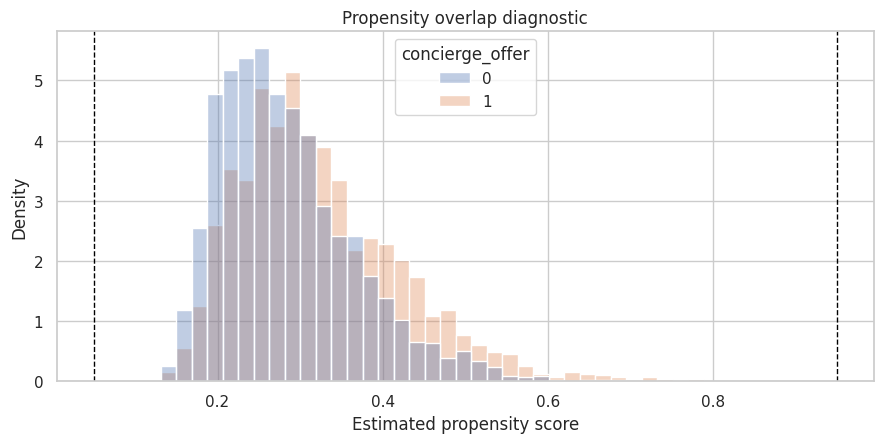

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.6))
sns.histplot(
    data=df_agent,
    x='propensity',
    hue='concierge_offer',
    bins=35,
    common_norm=False,
    stat='density',
    alpha=0.35,
    ax=ax,
)
ax.axvline(0.05, color='black', linestyle='--', linewidth=1)
ax.axvline(0.95, color='black', linestyle='--', linewidth=1)
ax.set_title('Propensity overlap diagnostic')
ax.set_xlabel('Estimated propensity score')
ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

## 11. Tool 5: Estimators

The agent runs several estimates, but it should not treat estimator disagreement as a nuisance. Disagreement is a diagnostic.

We compare:

- Naive treated-control difference.
- Regression adjustment using only pre-treatment covariates.
- IPW using the propensity score.
- AIPW using outcome models and propensity scores.
- A deliberately bad-control regression that includes a post-treatment variable.

In [16]:
def fit_regression_adjustment(data, outcome, treatment, covariates):
    formula = f"{outcome} ~ {treatment} + {rhs_from_covariates(covariates)}"
    model = smf.ols(formula, data=data).fit(cov_type='HC1')
    return {
        'method': 'regression_adjustment_pre_treatment',
        'formula': formula,
        'estimate': float(model.params[treatment]),
        'std_error': float(model.bse[treatment]),
        'ci_low': float(model.conf_int().loc[treatment, 0]),
        'ci_high': float(model.conf_int().loc[treatment, 1]),
        'p_value': float(model.pvalues[treatment]),
    }


def estimate_ipw(data, outcome, treatment, propensity_col='propensity'):
    y = data[outcome]
    t = data[treatment]
    p = data[propensity_col]
    estimate = (t * y / p - (1 - t) * y / (1 - p)).mean()
    return {'method': 'ipw', 'estimate': float(estimate)}


def estimate_aipw(data, outcome, treatment, covariates, propensity_col='propensity'):
    rhs = rhs_from_covariates(covariates)
    treated = data[data[treatment] == 1]
    control = data[data[treatment] == 0]
    m1 = smf.ols(f"{outcome} ~ {rhs}", data=treated).fit()
    m0 = smf.ols(f"{outcome} ~ {rhs}", data=control).fit()
    mu1 = m1.predict(data)
    mu0 = m0.predict(data)
    y = data[outcome]
    t = data[treatment]
    p = data[propensity_col]
    estimate = (mu1 - mu0 + t * (y - mu1) / p - (1 - t) * (y - mu0) / (1 - p)).mean()
    return {'method': 'aipw', 'estimate': float(estimate)}


regression_result = fit_regression_adjustment(df_agent, 'renewed_60d', 'concierge_offer', adjustment_set)
ipw_result = estimate_ipw(df_agent, 'renewed_60d', 'concierge_offer')
aipw_result = estimate_aipw(df_agent, 'renewed_60d', 'concierge_offer', adjustment_set)

bad_control_covariates = adjustment_set + ['support_contacts_after_offer']
bad_control_result = fit_regression_adjustment(df_agent, 'renewed_60d', 'concierge_offer', bad_control_covariates)
bad_control_result['method'] = 'bad_control_regression_includes_post_treatment'

estimate_table = pd.DataFrame([
    {'method': 'naive_difference', 'estimate': naive_difference, 'std_error': np.nan, 'ci_low': np.nan, 'ci_high': np.nan, 'p_value': np.nan},
    regression_result,
    {**ipw_result, 'std_error': np.nan, 'ci_low': np.nan, 'ci_high': np.nan, 'p_value': np.nan},
    {**aipw_result, 'std_error': np.nan, 'ci_low': np.nan, 'ci_high': np.nan, 'p_value': np.nan},
    bad_control_result,
    {'method': 'true_expected_ate_synthetic_only', 'estimate': true_ate, 'std_error': np.nan, 'ci_low': np.nan, 'ci_high': np.nan, 'p_value': np.nan},
])

agent_state['artifacts']['estimate_table'] = estimate_table.to_dict(orient='records')
record_step(agent_state, 'estimate_effects', 'completed', {'preferred_estimator': 'aipw'})
estimate_table

,method,estimate,std_error,ci_low,ci_high,p_value,formula
0,naive_difference,0.021940,NaN,NaN,NaN,NaN,NaN
1,regression_adjustment_pre_treatment,0.040211,0.011263,0.018136,0.062286,0.000357,renewed_60d ~ concierge_offer + C(segment) + t...
2,ipw,0.039099,NaN,NaN,NaN,NaN,NaN
3,aipw,0.039532,NaN,NaN,NaN,NaN,NaN
4,bad_control_regression_includes_post_treatment,0.041024,0.011647,0.018196,0.063851,0.000428,renewed_60d ~ concierge_offer + C(segment) + t...
5,true_expected_ate_synthetic_only,0.054033,NaN,NaN,NaN,NaN,NaN


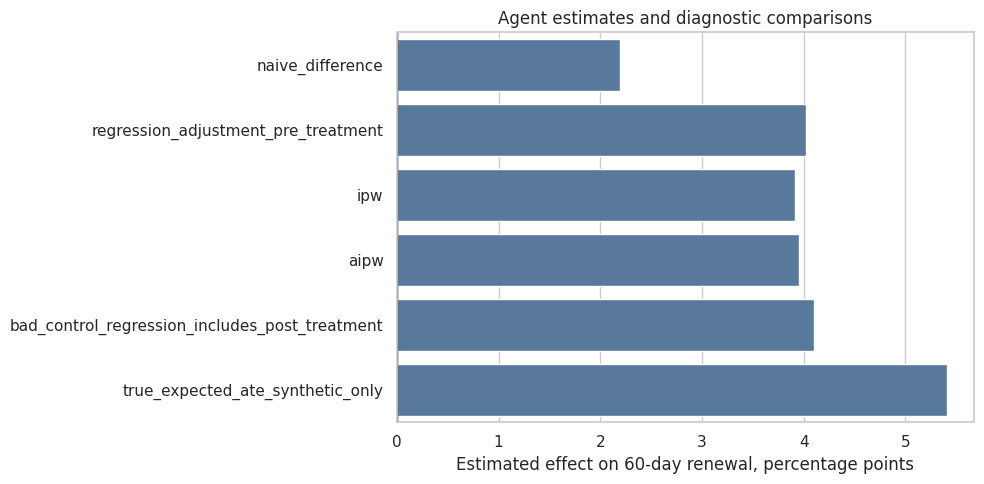

In [17]:
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = estimate_table.copy()
plot_df['estimate_pp'] = 100 * plot_df['estimate']
sns.barplot(data=plot_df, x='estimate_pp', y='method', color='#4C78A8', ax=ax)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Agent estimates and diagnostic comparisons')
ax.set_xlabel('Estimated effect on 60-day renewal, percentage points')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 12. Human Gates and Stop Conditions

The agent should not be allowed to continue just because code executed. It needs explicit gates.

For this project, the agent can proceed to a cautious report only if:

- The brief columns exist.
- No post-treatment controls are used in the preferred adjustment set.
- Overlap is adequate.
- Estimates from plausible methods are directionally consistent.
- The report states that the design depends on conditional exchangeability.

In [18]:
def evaluate_estimate_stability(estimate_table):
    plausible = estimate_table[estimate_table['method'].isin(['regression_adjustment_pre_treatment', 'ipw', 'aipw'])]
    signs_consistent = plausible['estimate'].gt(0).all() or plausible['estimate'].lt(0).all()
    spread = plausible['estimate'].max() - plausible['estimate'].min()
    return {
        'plausible_methods': plausible[['method', 'estimate']].to_dict(orient='records'),
        'signs_consistent': bool(signs_consistent),
        'spread_pp': float(100 * spread),
        'status': 'pass' if signs_consistent and spread < 0.05 else 'review',
    }


stability = evaluate_estimate_stability(estimate_table)
agent_state['artifacts']['estimate_stability'] = stability
record_gate(agent_state, 'plausible estimators directionally agree', stability['status'], f"spread = {stability['spread_pp']:.2f} pp")

pd.DataFrame(agent_state['gates'])

,gate,status,reason
0,all brief columns exist,pass,[]
1,no post-treatment controls in adjustment set,pass,bad controls excluded: ['support_contacts_afte...
2,overlap is adequate,pass,"share in [0.05, 0.95] = 1.000"
3,plausible estimators directionally agree,pass,spread = 0.11 pp


## 13. Deterministic Agent Run Summary

The deterministic agent can now create a compact run summary. This is the object an LLM should summarize, not replace.

In [19]:
def json_clean(value):
    if isinstance(value, (np.floating, float)) and np.isnan(value):
        return None
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    return value


def clean_record(record):
    cleaned = {key: json_clean(value) for key, value in record.items()}
    return {key: value for key, value in cleaned.items() if value is not None}


def build_agent_run_summary(state):
    estimates = pd.DataFrame(state['artifacts']['estimate_table'])
    preferred = clean_record(estimates.loc[estimates['method'] == 'aipw'].iloc[0].to_dict())
    gate_table = pd.DataFrame(state['gates'])
    status = 'ready_for_human_review' if not gate_table['status'].eq('fail').any() else 'halted'
    state['final_status'] = status
    return {
        'project_id': state['brief']['project_id'],
        'final_status': status,
        'recommended_design': state['artifacts']['design_plan']['recommended_design'],
        'estimand': state['artifacts']['estimand_card']['estimand'],
        'preferred_estimate': preferred,
        'diagnostics': {
            'overlap': state['artifacts']['overlap_diagnostics'],
            'estimate_stability': state['artifacts']['estimate_stability'],
            'gates': state['gates'],
        },
        'do_not_do': [
            'Do not use support_contacts_after_offer as an adjustment variable.',
            'Do not call this randomized evidence.',
            'Do not expand without human review of unobserved-confounding risk.',
        ],
        'brittleness_note': 'Agent outputs are brittle because planning, variable-role decisions, diagnostics, and report language can each fail and compound.',
    }


agent_run_summary = build_agent_run_summary(agent_state)
print(json.dumps(agent_run_summary, indent=2)[:4500])

{
  "project_id": "retention_concierge_observational_v1",
  "final_status": "ready_for_human_review",
  "recommended_design": "observational_adjustment",
  "estimand": "Average treatment effect of receiving the concierge offer among eligible customer accounts",
  "preferred_estimate": {
    "method": "aipw",
    "estimate": 0.03953175950386774
  },
  "diagnostics": {
    "overlap": {
      "min_propensity": 0.13148356328220018,
      "max_propensity": 0.7886534937694106,
      "share_between_05_95": 1.0,
      "effective_sample_size_ipw": 4381.418754943585,
      "status": "pass"
    },
    "estimate_stability": {
      "plausible_methods": [
        {
          "method": "regression_adjustment_pre_treatment",
          "estimate": 0.040211131308402474
        },
        {
          "method": "ipw",
          "estimate": 0.039099118209487665
        },
        {
          "method": "aipw",
          "estimate": 0.03953175950386774
        }
      ],
      "signs_consistent": true,
    

## 14. Deterministic Report From the Agent

The report is cautious because the design is observational. It should recommend human review, not autonomous rollout.

In [20]:
def build_agent_report(summary):
    estimate = summary['preferred_estimate']['estimate']
    gates = pd.DataFrame(summary['diagnostics']['gates'])
    gate_lines = '\n'.join(f"- {row.gate}: {row.status} ({row.reason})" for row in gates.itertuples())
    return f"""
### Causal Agent Run Report

**Project.** {summary['project_id']}

**Design selected.** {summary['recommended_design']}. The design relies on conditional exchangeability after observed pre-treatment adjustment.

**Estimand.** {summary['estimand']}

**Preferred estimate.** The AIPW estimate suggests a {100 * estimate:.1f} percentage point effect on 60-day renewal. Because this is observational evidence, this should be treated as decision support rather than definitive proof.

**Gates.**
{gate_lines}

**Key caution.** The post-treatment variable `support_contacts_after_offer` was excluded from the preferred adjustment set. Including it would create bad-control bias.

**Brittleness note.** A causal analysis agent can fail through compounding errors across planning, tool calls, diagnostics, and report generation. This run should be reviewed before any rollout decision.
""".strip()


agent_report = build_agent_report(agent_run_summary)
display(Markdown(agent_report))

### Causal Agent Run Report

**Project.** retention_concierge_observational_v1

**Design selected.** observational_adjustment. The design relies on conditional exchangeability after observed pre-treatment adjustment.

**Estimand.** Average treatment effect of receiving the concierge offer among eligible customer accounts

**Preferred estimate.** The AIPW estimate suggests a 4.0 percentage point effect on 60-day renewal. Because this is observational evidence, this should be treated as decision support rather than definitive proof.

**Gates.**
- all brief columns exist: pass ([])
- no post-treatment controls in adjustment set: pass (bad controls excluded: ['support_contacts_after_offer'])
- overlap is adequate: pass (share in [0.05, 0.95] = 1.000)
- plausible estimators directionally agree: pass (spread = 0.11 pp)

**Key caution.** The post-treatment variable `support_contacts_after_offer` was excluded from the preferred adjustment set. Including it would create bad-control bias.

**Brittleness note.** A causal analysis agent can fail through compounding errors across planning, tool calls, diagnostics, and report generation. This run should be reviewed before any rollout decision.

## 15. Optional LLM Agent Planner

Now we ask a local model to produce an agent plan from the project brief and data profile. The model does not get to run the analysis. It only proposes a plan that we can score.

In [21]:
class CausalAgentPlan(BaseModel):
    project_summary: str
    estimand: str
    recommended_design: Literal['randomized_experiment', 'observational_adjustment', 'difference_in_differences', 'regression_discontinuity', 'do_not_analyze_yet']
    adjustment_set: list[str] = Field(default_factory=list)
    excluded_variables: list[str] = Field(default_factory=list)
    tool_sequence: list[str] = Field(default_factory=list)
    human_review_gates: list[str] = Field(default_factory=list)
    risks_and_failure_modes: list[str] = Field(default_factory=list)
    stop_conditions: list[str] = Field(default_factory=list)
    final_output_artifacts: list[str] = Field(default_factory=list)
    confidence: Literal['low', 'medium', 'high']


PLAN_FIELD_ALIASES = {
    'summary': 'project_summary',
    'design': 'recommended_design',
    'method': 'recommended_design',
    'covariates': 'adjustment_set',
    'controls': 'adjustment_set',
    'exclude': 'excluded_variables',
    'excluded': 'excluded_variables',
    'tools': 'tool_sequence',
    'tool_calls': 'tool_sequence',
    'gates': 'human_review_gates',
    'human_gates': 'human_review_gates',
    'risks': 'risks_and_failure_modes',
    'failure_modes': 'risks_and_failure_modes',
    'outputs': 'final_output_artifacts',
}

PLAN_VALUE_ALIASES = {
    'recommended_design': {
        'observational': 'observational_adjustment',
        'observational adjustment': 'observational_adjustment',
        'propensity score': 'observational_adjustment',
        'aipw': 'observational_adjustment',
        'experiment': 'randomized_experiment',
        'randomized': 'randomized_experiment',
        'did': 'difference_in_differences',
        'diff in diff': 'difference_in_differences',
        'difference in differences': 'difference_in_differences',
        'rdd': 'regression_discontinuity',
        'regression discontinuity': 'regression_discontinuity',
        'do not analyze': 'do_not_analyze_yet',
    },
    'confidence': {'moderate': 'medium', 'cautious': 'medium', 'uncertain': 'low'},
}

PLAN_DEFAULTS = {
    'project_summary': '',
    'estimand': '',
    'recommended_design': 'do_not_analyze_yet',
    'adjustment_set': [],
    'excluded_variables': [],
    'tool_sequence': [],
    'human_review_gates': [],
    'risks_and_failure_modes': [],
    'stop_conditions': [],
    'final_output_artifacts': [],
    'confidence': 'medium',
}

In [22]:
AGENT_SYSTEM_MESSAGE = """
You are a careful causal inference workflow planner. You design auditable causal analysis agents.
Do not invent columns. Do not use post-treatment variables as controls. Return final JSON only.
""".strip()


def plan_schema_prompt():
    return """
Produce one CausalAgentPlan JSON object only.

Schema:
{
  "project_summary": "string",
  "estimand": "string",
  "recommended_design": "randomized_experiment | observational_adjustment | difference_in_differences | regression_discontinuity | do_not_analyze_yet",
  "adjustment_set": ["string"],
  "excluded_variables": ["string"],
  "tool_sequence": ["string"],
  "human_review_gates": ["string"],
  "risks_and_failure_modes": ["string"],
  "stop_conditions": ["string"],
  "final_output_artifacts": ["string"],
  "confidence": "low | medium | high"
}
""".strip()


def build_agent_plan_prompt(brief, role_table, profile):
    compact_profile = {
        'n_rows': profile['n_rows'],
        'treatment_share': profile['treatment_share'],
        'outcome_rate': profile['outcome_rate'],
        'missing_columns_from_brief': profile['missing_columns_from_brief'],
    }
    return f"""
{plan_schema_prompt()}

Project brief:
{json.dumps(brief, indent=2)}

Variable dictionary:
{json.dumps(role_table.to_dict(orient='records'), indent=2)}

Data profile:
{json.dumps(compact_profile, indent=2)}

Requirements:
- Identify this as observational unless the brief clearly says treatment was randomized.
- Exclude post-treatment variables from adjustment.
- Include overlap, balance, bad-control, estimator-stability, and report-audit tools.
- Include human review gates and stop conditions.
- Mention brittleness of agentic causal workflows.
""".strip()


agent_plan_prompt = build_agent_plan_prompt(project_brief, role_table, profile)
print(agent_plan_prompt[:2800])

Produce one CausalAgentPlan JSON object only.

Schema:
{
  "project_summary": "string",
  "estimand": "string",
  "recommended_design": "randomized_experiment | observational_adjustment | difference_in_differences | regression_discontinuity | do_not_analyze_yet",
  "adjustment_set": ["string"],
  "excluded_variables": ["string"],
  "tool_sequence": ["string"],
  "human_review_gates": ["string"],
  "risks_and_failure_modes": ["string"],
  "stop_conditions": ["string"],
  "final_output_artifacts": ["string"],
  "confidence": "low | medium | high"
}

Project brief:
{
  "project_id": "retention_concierge_observational_v1",
  "decision": "Should the company expand a concierge retention offer to more at-risk subscription customers?",
  "unit": "customer_account",
  "treatment": "concierge_offer",
  "outcome": "renewed_60d",
  "time_horizon": "60 days after offer eligibility",
  "assignment_context": "Customer-success managers prioritized accounts using churn-risk signals and available capaci

In [23]:
try:
    from notebooks._shared.local_llm import clear_loaded_model_cache, local_chat
    from notebooks._shared.structured_outputs import parse_pydantic_output
except Exception as exc:
    clear_loaded_model_cache = None
    local_chat = None
    parse_pydantic_output = None
    print(f'Could not import shared LLM helpers: {exc}')


def release_model_memory():
    if clear_loaded_model_cache is None:
        return
    try:
        clear_loaded_model_cache()
    except Exception as exc:
        print(f'Could not clear loaded model cache: {exc}')

In [24]:
def parse_agent_plan(raw_output):
    if parse_pydantic_output is None:
        raise RuntimeError('parse_pydantic_output is unavailable')
    return parse_pydantic_output(
        raw_output,
        CausalAgentPlan,
        scalar_fields=['project_summary', 'estimand', 'recommended_design', 'confidence'],
        list_fields=['adjustment_set', 'excluded_variables', 'tool_sequence', 'human_review_gates', 'risks_and_failure_modes', 'stop_conditions', 'final_output_artifacts'],
        field_aliases=PLAN_FIELD_ALIASES,
        value_aliases=PLAN_VALUE_ALIASES,
        defaults=PLAN_DEFAULTS,
    )


raw_agent_plan = None
parsed_agent_plan = None
agent_plan_parse_error = None

if RUN_LIVE_LOCAL_LLM and local_chat is not None and parse_pydantic_output is not None:
    release_model_memory()
    raw_agent_plan = local_chat(
        agent_plan_prompt,
        system_message=AGENT_SYSTEM_MESSAGE,
        model_id=MODEL_ID,
        max_new_tokens=MAX_NEW_TOKENS,
        temperature=TEMPERATURE,
        seed=SEED,
        enabled=RUN_LIVE_LOCAL_LLM,
    )
    print(raw_agent_plan[:3500])
    try:
        parsed_result = parse_agent_plan(raw_agent_plan)
        parsed_agent_plan = parsed_result.parsed
        if parsed_result.notes:
            print('Parser notes:', parsed_result.notes)
    except Exception as exc:
        agent_plan_parse_error = exc
        print(f'Parsing failed: {exc}')
    finally:
        release_model_memory()
else:
    print('RUN_LIVE_LOCAL_LLM is False. Skipping live local agent planning.')

{
 "project_summary": "Analyze the impact of a concierge retention offer on customer renewal rates within 60 days, considering potential confounders and ensuring robust causal inference.",
 "estimand": "The average treatment effect (ATE) of the concierge offer on customer renewals within 60 days.",
 "recommended_design": "observational_adjustment",
 "adjustment_set": ["segment", "tenure_months", "monthly_spend", "prior_usage_30d", "support_tickets_prior_30d", "risk_score_pre"],
 "excluded_variables": ["support_contacts_after_offer", "renewed_60d"],
 "tool_sequence": ["overlap_check", "balance_check", "bad_control_identification", "estimator_stability_check", "report_audit"],
 "human_review_gates": ["initial_balance_review", "final_estimator_stability_review"],
 "risks_and_failure_modes": ["Selection bias due to non-random assignment", "Unmeasured confounding", "Model misspecification"],
 "stop_conditions": ["Significant imbalance detected", "Estimator instability observed", "Substantia

In [25]:
if parsed_agent_plan is not None:
    display(Markdown(f"### LLM Agent Plan: `{parsed_agent_plan.recommended_design}`"))
    display(Markdown(parsed_agent_plan.project_summary))
    display(Markdown('**Adjustment set**\n' + '\n'.join(f'- `{item}`' for item in parsed_agent_plan.adjustment_set)))
    display(Markdown('**Human review gates**\n' + '\n'.join(f'- {item}' for item in parsed_agent_plan.human_review_gates)))
else:
    print('No parsed LLM agent plan is available yet.')

### LLM Agent Plan: `observational_adjustment`

Analyze the impact of a concierge retention offer on customer renewal rates within 60 days, considering potential confounders and ensuring robust causal inference.

**Adjustment set**
- `segment`
- `tenure_months`
- `monthly_spend`
- `prior_usage_30d`
- `support_tickets_prior_30d`
- `risk_score_pre`

**Human review gates**
- initial_balance_review
- final_estimator_stability_review

## 16. Auditing the LLM Agent Plan

The audit checks whether the plan preserves core causal safeguards. The score is not a measure of intelligence. It is a checklist for whether the generated plan is safe enough to discuss.

In [26]:
def contains_any(text, patterns):
    text_lower = text.lower()
    return any(pattern.lower() in text_lower for pattern in patterns)


def score_agent_plan(plan, known_columns):
    if plan is None:
        return pd.DataFrame([{'criterion': 'parsed plan exists', 'passed': False, 'score': 0}])

    text = ' '.join([
        plan.project_summary,
        plan.estimand,
        plan.recommended_design,
        ' '.join(plan.adjustment_set),
        ' '.join(plan.excluded_variables),
        ' '.join(plan.tool_sequence),
        ' '.join(plan.human_review_gates),
        ' '.join(plan.risks_and_failure_modes),
        ' '.join(plan.stop_conditions),
        ' '.join(plan.final_output_artifacts),
    ]).lower()
    hallucinated_adjusters = sorted(set(plan.adjustment_set) - set(known_columns))

    checks = {
        'chooses observational adjustment': plan.recommended_design == 'observational_adjustment',
        'includes pre-treatment risk/usage confounders': {'risk_score_pre', 'prior_usage_30d'}.issubset(set(plan.adjustment_set)),
        'excludes post-treatment support contacts': 'support_contacts_after_offer' in set(plan.excluded_variables) and 'support_contacts_after_offer' not in set(plan.adjustment_set),
        'mentions overlap or propensity diagnostics': contains_any(text, ['overlap', 'propensity', 'common support']),
        'mentions bad controls': contains_any(text, ['bad control', 'post-treatment', 'post treatment']),
        'mentions human review gates': len(plan.human_review_gates) >= 2,
        'mentions unobserved confounding risk': contains_any(text, ['unobserved', 'exchangeability', 'hidden confounding']),
        'mentions brittleness or compounding errors': contains_any(text, ['brittle', 'rerun', 'compound', 'audit', 'model output']),
        'does not hallucinate adjustment columns': len(hallucinated_adjusters) == 0,
        'does not claim randomized evidence': not contains_any(text, ['randomized evidence', 'random assignment']) or contains_any(text, ['not randomized', 'not random']),
    }
    out = pd.DataFrame([
        {'criterion': key, 'passed': bool(value), 'score': int(bool(value))}
        for key, value in checks.items()
    ])
    if hallucinated_adjusters:
        print('Hallucinated adjustment columns:', hallucinated_adjusters)
    return out


agent_plan_score = score_agent_plan(parsed_agent_plan, df.columns)
agent_plan_score

,criterion,passed,score
0,chooses observational adjustment,True,1
1,includes pre-treatment risk/usage confounders,True,1
2,excludes post-treatment support contacts,True,1
3,mentions overlap or propensity diagnostics,True,1
4,mentions bad controls,False,0
5,mentions human review gates,True,1
6,mentions unobserved confounding risk,False,0
7,mentions brittleness or compounding errors,True,1
8,does not hallucinate adjustment columns,True,1
9,does not claim randomized evidence,False,0


## 17. Optional All-Model Agent-Planning Comparison

We now compare model families on compact agent-planning cases. This comparison is intentionally strict: a model gets credit for choosing a conservative design, naming required tools, adding human gates, and mentioning agent brittleness.

In [27]:
class CompactAgentDecision(BaseModel):
    design: Literal['randomized_experiment', 'observational_adjustment', 'difference_in_differences', 'regression_discontinuity', 'do_not_analyze_yet']
    should_proceed: Literal['yes_with_human_review', 'needs_more_information', 'no']
    required_tools: list[str] = Field(default_factory=list)
    human_gates: list[str] = Field(default_factory=list)
    excluded_variables: list[str] = Field(default_factory=list)
    risk_flags: list[str] = Field(default_factory=list)
    confidence: Literal['low', 'medium', 'high']


COMPACT_FIELD_ALIASES = {
    'recommended_design': 'design',
    'method': 'design',
    'proceed': 'should_proceed',
    'tools': 'required_tools',
    'gates': 'human_gates',
    'risks': 'risk_flags',
    'excluded': 'excluded_variables',
}

COMPACT_VALUE_ALIASES = {
    **PLAN_VALUE_ALIASES,
    'should_proceed': {
        'yes': 'yes_with_human_review',
        'yes with review': 'yes_with_human_review',
        'proceed with human review': 'yes_with_human_review',
        'needs information': 'needs_more_information',
        'needs more information': 'needs_more_information',
        'no': 'no',
        'halt': 'no',
    },
}

COMPACT_DEFAULTS = {
    'design': 'do_not_analyze_yet',
    'should_proceed': 'needs_more_information',
    'required_tools': [],
    'human_gates': [],
    'excluded_variables': [],
    'risk_flags': [],
    'confidence': 'medium',
}

In [28]:
AGENT_EVAL_CASES = [
    {
        'case_name': 'randomized_email_holdout',
        'brief': 'A marketing team randomly held out 10% of eligible users from an email campaign. Outcome is purchase within 14 days.',
        'columns': ['randomized_email', 'purchase_14d', 'segment', 'prior_spend', 'send_week'],
        'expected_design': 'randomized_experiment',
        'expected_risk': 'check randomization balance and guardrails',
    },
    {
        'case_name': 'targeted_retention_offer',
        'brief': 'High-risk subscribers were targeted for a concierge retention offer. Outcome is renewal within 60 days. There is a post-offer support-contact variable.',
        'columns': ['concierge_offer', 'renewed_60d', 'risk_score_pre', 'prior_usage_30d', 'support_contacts_after_offer', 'segment'],
        'expected_design': 'observational_adjustment',
        'expected_risk': 'exclude post-treatment support contacts and check overlap',
    },
    {
        'case_name': 'staggered_policy_rollout',
        'brief': 'A pricing policy rolled out to regions in different months. Outcome is monthly gross margin. Regions have multiple pre-rollout months.',
        'columns': ['region', 'month', 'policy_active', 'gross_margin', 'pre_policy_trend', 'region_size'],
        'expected_design': 'difference_in_differences',
        'expected_risk': 'check pre-trends, timing, and spillovers',
    },
]

AGENT_EVAL_CASES

[{'case_name': 'randomized_email_holdout',
  'brief': 'A marketing team randomly held out 10% of eligible users from an email campaign. Outcome is purchase within 14 days.',
  'columns': ['randomized_email',
   'purchase_14d',
   'segment',
   'prior_spend',
   'send_week'],
  'expected_design': 'randomized_experiment',
  'expected_risk': 'check randomization balance and guardrails'},
 {'case_name': 'targeted_retention_offer',
  'brief': 'High-risk subscribers were targeted for a concierge retention offer. Outcome is renewal within 60 days. There is a post-offer support-contact variable.',
  'columns': ['concierge_offer',
   'renewed_60d',
   'risk_score_pre',
   'prior_usage_30d',
   'support_contacts_after_offer',
   'segment'],
  'expected_design': 'observational_adjustment',
  'expected_risk': 'exclude post-treatment support contacts and check overlap'},
 {'case_name': 'staggered_policy_rollout',
  'brief': 'A pricing policy rolled out to regions in different months. Outcome is mon

In [29]:
def compact_agent_prompt(case):
    return f"""
Return one CompactAgentDecision JSON object only.

Schema:
{{
  "design": "randomized_experiment | observational_adjustment | difference_in_differences | regression_discontinuity | do_not_analyze_yet",
  "should_proceed": "yes_with_human_review | needs_more_information | no",
  "required_tools": ["string"],
  "human_gates": ["string"],
  "excluded_variables": ["string"],
  "risk_flags": ["string"],
  "confidence": "low | medium | high"
}}

Case:
{json.dumps(case, indent=2)}

Rules:
- Do not invent columns.
- Name tools and human gates.
- Mention brittleness or compounding agent errors.
- Be conservative when design assumptions are not credible.
""".strip()


def parse_compact_agent_decision(raw_output):
    if parse_pydantic_output is None:
        raise RuntimeError('parse_pydantic_output is unavailable')
    return parse_pydantic_output(
        raw_output,
        CompactAgentDecision,
        scalar_fields=['design', 'should_proceed', 'confidence'],
        list_fields=['required_tools', 'human_gates', 'excluded_variables', 'risk_flags'],
        field_aliases=COMPACT_FIELD_ALIASES,
        value_aliases=COMPACT_VALUE_ALIASES,
        defaults=COMPACT_DEFAULTS,
    )


def score_compact_agent_decision(decision, case):
    text = ' '.join([
        decision.design,
        decision.should_proceed,
        ' '.join(decision.required_tools),
        ' '.join(decision.human_gates),
        ' '.join(decision.excluded_variables),
        ' '.join(decision.risk_flags),
    ]).lower()
    checks = {
        'design matches expected': decision.design == case['expected_design'],
        'requires human gate': len(decision.human_gates) >= 1 or decision.should_proceed != 'yes_with_human_review',
        'mentions relevant diagnostic risk': contains_any(text, case['expected_risk'].split()),
        'mentions brittleness or compounding errors': contains_any(text, ['brittle', 'compound', 'audit', 'model output', 'rerun']),
        'does not proceed without review': decision.should_proceed != 'yes' and decision.should_proceed in {'yes_with_human_review', 'needs_more_information', 'no'},
    }
    if case['case_name'] == 'targeted_retention_offer':
        checks['excludes post-treatment variable'] = 'support_contacts_after_offer' in set(decision.excluded_variables)
    return int(sum(checks.values())), checks

In [30]:
def run_all_model_agent_comparison(models_to_compare=MODELS_TO_COMPARE, cases=AGENT_EVAL_CASES):
    rows = []
    failures = []
    selected_cases = cases[:MODEL_COMPARISON_CASE_LIMIT]
    if local_chat is None or parse_pydantic_output is None:
        return pd.DataFrame(), [{'error': 'shared LLM helpers unavailable'}]

    for label, model_id, role in models_to_compare:
        release_model_memory()
        print(f'Running {label}: {model_id}')
        try:
            for case in selected_cases:
                try:
                    raw = local_chat(
                        compact_agent_prompt(case),
                        system_message=AGENT_SYSTEM_MESSAGE,
                        model_id=model_id,
                        max_new_tokens=COMPACT_MAX_NEW_TOKENS,
                        temperature=TEMPERATURE,
                        seed=SEED,
                        enabled=True,
                    )
                    parsed = parse_compact_agent_decision(raw)
                    score, checks = score_compact_agent_decision(parsed.parsed, case)
                    rows.append({
                        'model': label,
                        'model_id': model_id,
                        'role': role,
                        'case': case['case_name'],
                        'design': parsed.parsed.design,
                        'should_proceed': parsed.parsed.should_proceed,
                        'score': score,
                        'max_score': len(checks),
                        'failed_checks': ', '.join([key for key, passed in checks.items() if not passed]),
                        'parser_notes': '; '.join(parsed.notes),
                    })
                except Exception as exc:
                    failures.append({'model': label, 'model_id': model_id, 'case': case['case_name'], 'error': repr(exc)})
        finally:
            release_model_memory()
    return pd.DataFrame(rows), failures


if RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM:
    agent_model_comparison, agent_model_failures = run_all_model_agent_comparison()
else:
    agent_model_comparison = pd.DataFrame()
    agent_model_failures = []
    print('Full model comparison skipped. Set RUN_FULL_MODEL_COMPARISON and RUN_LIVE_LOCAL_LLM to True to run it.')

Running Qwen 0.5B: Qwen/Qwen2.5-0.5B-Instruct
Running Qwen 7B: Qwen/Qwen2.5-7B-Instruct
Running Qwen 14B: Qwen/Qwen2.5-14B-Instruct
Running Qwen 32B: Qwen/Qwen2.5-32B-Instruct
Running Phi mini: microsoft/Phi-3.5-mini-instruct


[transformers] This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.


Running Mistral 7B: mistralai/Mistral-7B-Instruct-v0.3
Running Mistral Small 24B: mistralai/Mistral-Small-3.1-24B-Instruct-2503


[transformers] The tied weights mapping and config for this model specifies to tie model.language_model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Running Gemma 3 27B: google/gemma-3-27b-it
Running Llama 3.1 8B: meta-llama/Meta-Llama-3.1-8B-Instruct


In [31]:
if len(agent_model_comparison):
    display(agent_model_comparison.sort_values(['score', 'model', 'case'], ascending=[False, True, True]).reset_index(drop=True))
else:
    print('No model-comparison results yet.')

,model,model_id,role,case,design,should_proceed,score,max_score,failed_checks,parser_notes
0,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,targeted_retention_offer,observational_adjustment,yes_with_human_review,6,6,,Invalid JSON: expected value at line 1 column ...
1,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,targeted_retention_offer,observational_adjustment,yes_with_human_review,6,6,,
2,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,targeted_retention_offer,observational_adjustment,yes_with_human_review,6,6,,Invalid JSON: expected value at line 1 column ...
3,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison,targeted_retention_offer,observational_adjustment,yes_with_human_review,6,6,,
4,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default,targeted_retention_offer,observational_adjustment,needs_more_information,6,6,,
5,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,randomized_email_holdout,randomized_experiment,yes_with_human_review,5,5,,Invalid JSON: expected value at line 1 column ...
6,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,randomized_email_holdout,randomized_experiment,yes_with_human_review,5,5,,
7,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,staggered_policy_rollout,difference_in_differences,yes_with_human_review,5,5,,
8,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,randomized_email_holdout,randomized_experiment,needs_more_information,5,5,,
9,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,staggered_policy_rollout,difference_in_differences,needs_more_information,5,5,,


In [32]:
if len(agent_model_comparison):
    summary = (
        agent_model_comparison
        .groupby(['model', 'model_id', 'role'], as_index=False)
        .agg(mean_score=('score', 'mean'), min_score=('score', 'min'), cases=('case', 'nunique'))
        .sort_values(['mean_score', 'min_score'], ascending=False)
    )
    display(summary)
else:
    print('No model-comparison summary yet.')

if agent_model_failures:
    display(pd.DataFrame(agent_model_failures))
else:
    print('No failed model details because the full comparison was skipped or all calls parsed.')

,model,model_id,role,mean_score,min_score,cases
1,Llama 3.1 8B,meta-llama/Meta-Llama-3.1-8B-Instruct,industry-standard instruct baseline,5.333333,5,3
3,Mistral Small 24B,mistralai/Mistral-Small-3.1-24B-Instruct-2503,strong non-Qwen comparison,5.333333,5,3
2,Mistral 7B,mistralai/Mistral-7B-Instruct-v0.3,7B model-family comparison,5.000000,5,3
0,Gemma 3 27B,google/gemma-3-27b-it,large non-Qwen comparison,5.000000,4,3
4,Phi mini,microsoft/Phi-3.5-mini-instruct,compact non-Qwen comparison,5.000000,4,3
8,Qwen 7B,Qwen/Qwen2.5-7B-Instruct,fast default,5.000000,4,3
7,Qwen 32B,Qwen/Qwen2.5-32B-Instruct,scale comparison,4.666667,4,3
6,Qwen 14B,Qwen/Qwen2.5-14B-Instruct,strong local analysis,4.333333,3,3
5,Qwen 0.5B,Qwen/Qwen2.5-0.5B-Instruct,pipeline smoke test,3.333333,3,3


No failed model details because the full comparison was skipped or all calls parsed.


## 18. Agent Design Checklist

Before trusting a causal analysis agent, check that it has:

1. A structured state object.
2. An estimand card before modeling.
3. A variable-role screen before adjustment.
4. Explicit exclusion of post-treatment variables.
5. Design selection with assumptions.
6. Overlap, balance, and estimator-stability diagnostics.
7. Human review gates and stop conditions.
8. A report grounded in computed artifacts.
9. A model-output audit for hallucinated columns and overconfident language.
10. Memory cleanup between large local model calls.

## 19. Exercises

1. Add a synthetic unobserved confounder to the data-generating process. How should the agent report the residual risk?
2. Make overlap worse by targeting only the highest-risk customers. Does the overlap gate stop the workflow?
3. Add a randomized-holdout flag to the brief and modify the design selector to choose an experiment.
4. Add an agent tool that writes a minimal analysis plan for a stakeholder before any estimation code is run.
5. Run the all-model comparison and inspect which models fail to exclude `support_contacts_after_offer`.
6. Extend the agent state so each artifact records the tool version, timestamp, and reviewer approval.

## 20. Key Takeaways

- A causal analysis agent should orchestrate tools, not replace identification thinking.
- Deterministic tools should own profiling, diagnostics, and estimation.
- The LLM should be constrained to planning, critique, translation, and report drafting.
- Human review gates are not decoration. They are part of the causal design.
- Agentic workflows are brittle because errors compound across steps. The remedy is structure, memory cleanup, explicit stop conditions, and auditability.